In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

df = pd.read_csv("/content/Dataset .csv")
print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(9551, 21)


In [ ]:
# Level 3 - Task 1: Restaurant Reviews

# Common positive and negative keywords to search for
positive_keywords = ["good", "great", "excellent", "amazing", "best",
                     "delicious", "wonderful", "fantastic", "loved", "fresh",
                     "tasty", "nice", "perfect", "friendly", "recommended"]

negative_keywords = ["bad", "worst", "terrible", "awful", "horrible",
                     "poor", "disappointing", "dirty", "slow", "overpriced",
                     "cold", "rude", "disgusting", "bland", "avoid"]

# Check which text columns are available
print("Columns:", df.columns.tolist())
text_col = None
for col in ["Rating text", "Cuisines", "Restaurant Name"]:
    if col in df.columns:
        print(f"Using column: {col}")
        text_col = col
        break

Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']
Using column: Rating text


Positive Keyword Counts:
  good            : 3179
  excellent       : 301
  great           : 0
  amazing         : 0
  best            : 0
  delicious       : 0
  wonderful       : 0
  fantastic       : 0
  loved           : 0
  fresh           : 0
  tasty           : 0
  nice            : 0
  perfect         : 0
  friendly        : 0
  recommended     : 0

Negative Keyword Counts:
  poor            : 186
  bad             : 0
  worst           : 0
  terrible        : 0
  awful           : 0
  horrible        : 0
  disappointing   : 0
  dirty           : 0
  slow            : 0
  overpriced      : 0
  cold            : 0
  rude            : 0
  disgusting      : 0
  bland           : 0
  avoid           : 0

Average Review Length: 7.02 characters
Correlation between Review Length and Rating: 0.1922


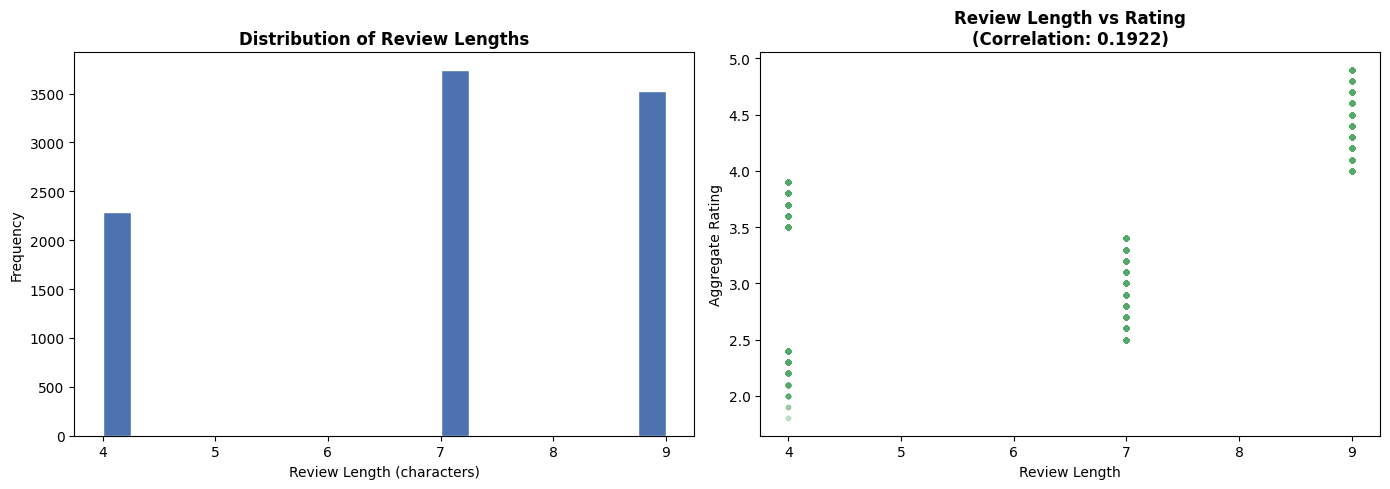

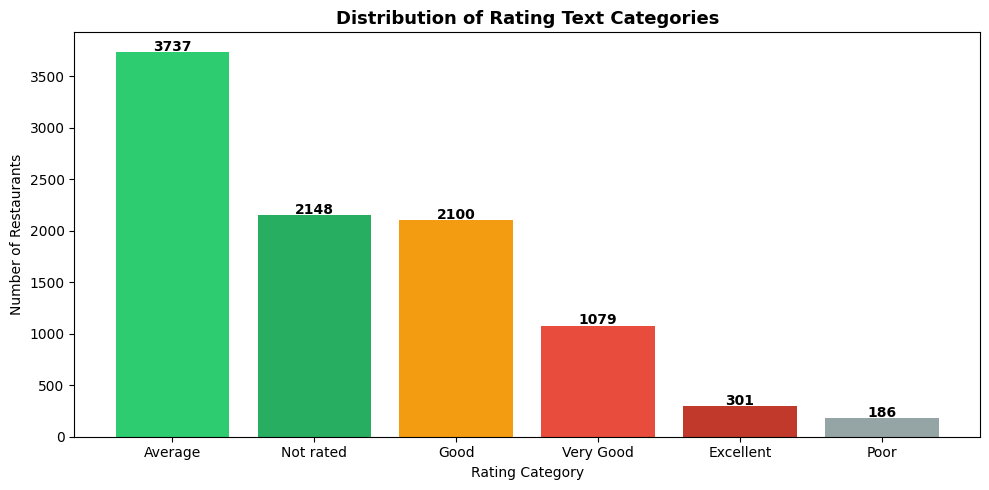

In [ ]:
# Level 3 - Task 1 continued: Rating Text Analysis

# Use 'Rating text' column for keyword analysis
if "Rating text" in df.columns:
    rating_text = df["Rating text"].dropna().str.lower()

    # Count positive keywords in rating text
    pos_counts = {}
    for word in positive_keywords:
        pos_counts[word] = rating_text.str.contains(word).sum()

    # Count negative keywords in rating text
    neg_counts = {}
    for word in negative_keywords:
        neg_counts[word] = rating_text.str.contains(word).sum()

    print("Positive Keyword Counts:")
    print("=" * 35)
    for word, cnt in sorted(pos_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {word:<15} : {cnt}")

    print("\nNegative Keyword Counts:")
    print("=" * 35)
    for word, cnt in sorted(neg_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {word:<15} : {cnt}")

# Review length = length of Rating text
df["Review Length"] = df["Rating text"].fillna("").apply(len)
avg_len = df["Review Length"].mean()
print(f"\nAverage Review Length: {avg_len:.2f} characters")

# Relationship between review length and rating
rated = df[df["Aggregate rating"] > 0]
correlation = rated["Review Length"].corr(rated["Aggregate rating"])
print(f"Correlation between Review Length and Rating: {correlation:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review length distribution
axes[0].hist(df["Review Length"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Review Lengths", fontweight="bold")
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Frequency")

# Review length vs rating
axes[1].scatter(rated["Review Length"], rated["Aggregate rating"],
                alpha=0.3, color="#55A868", s=10)
axes[1].set_title(f"Review Length vs Rating\n(Correlation: {correlation:.4f})",
                  fontweight="bold")
axes[1].set_xlabel("Review Length")
axes[1].set_ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

# Bar chart of rating text categories
rating_text_counts = df["Rating text"].value_counts()
plt.figure(figsize=(10, 5))
bars = plt.bar(rating_text_counts.index, rating_text_counts.values,
               color=["#2ecc71","#27ae60","#f39c12","#e74c3c","#c0392b","#95a5a6","#7f8c8d"])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(bar.get_height()),
             ha="center", fontweight="bold")
plt.title("Distribution of Rating Text Categories", fontweight="bold", fontsize=13)
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

Restaurant with HIGHEST Votes:
  Name   : Toit
  Votes  : 10934
  Rating : 4.8
  City   : Bangalore

Restaurant with LOWEST Votes:
  Name   : Cantinho da Gula
  Votes  : 0
  Rating : 0.0
  City   : S��o Paulo

Top 10 Most Voted Restaurants:
          Restaurant Name  Votes  Aggregate rating      City
                     Toit  10934               4.8 Bangalore
                 Truffles   9667               4.7 Bangalore
         Hauz Khas Social   7931               4.3 New Delhi
                Peter Cat   7574               4.3   Kolkata
AB's - Absolute Barbecues   6907               4.6 Bangalore
          Barbeque Nation   5966               4.9   Kolkata
              Big Brewsky   5705               4.5 Bangalore
AB's - Absolute Barbecues   5434               4.9 Hyderabad
          The Black Pearl   5385               4.1 Bangalore
                    BarBQ   5288               4.2   Kolkata

Correlation between Votes and Rating: 0.4090


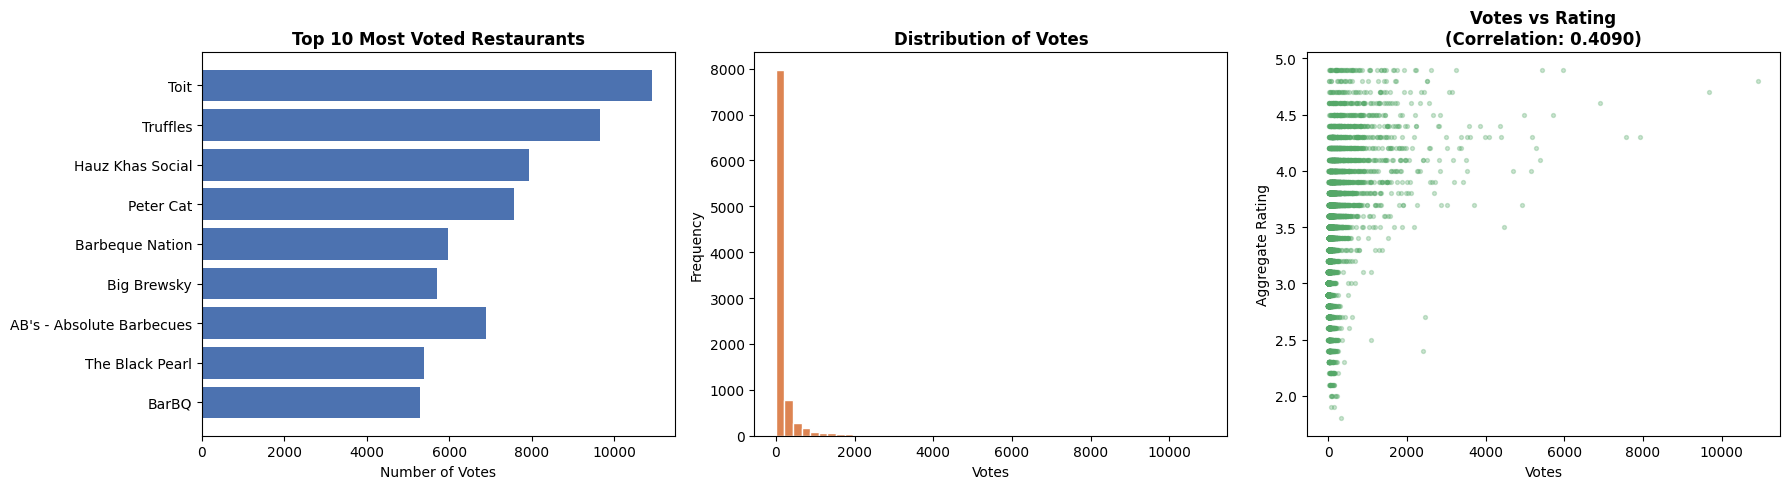

In [ ]:
# Level 3 - Task 2: Votes Analysis

# Restaurants with highest and lowest votes
max_votes_idx = df["Votes"].idxmax()
min_votes_idx = df["Votes"].idxmin()

print("Restaurant with HIGHEST Votes:")
print("=" * 45)
print(f"  Name   : {df.loc[max_votes_idx, 'Restaurant Name']}")
print(f"  Votes  : {df.loc[max_votes_idx, 'Votes']}")
print(f"  Rating : {df.loc[max_votes_idx, 'Aggregate rating']}")
print(f"  City   : {df.loc[max_votes_idx, 'City']}")

print("\nRestaurant with LOWEST Votes:")
print("=" * 45)
print(f"  Name   : {df.loc[min_votes_idx, 'Restaurant Name']}")
print(f"  Votes  : {df.loc[min_votes_idx, 'Votes']}")
print(f"  Rating : {df.loc[min_votes_idx, 'Aggregate rating']}")
print(f"  City   : {df.loc[min_votes_idx, 'City']}")

# Top 10 most voted restaurants
print("\nTop 10 Most Voted Restaurants:")
print("=" * 55)
top10_votes = df.nlargest(10, "Votes")[["Restaurant Name", "Votes", "Aggregate rating", "City"]]
print(top10_votes.to_string(index=False))

# Correlation between votes and rating
rated = df[df["Aggregate rating"] > 0]
correlation = rated["Votes"].corr(rated["Aggregate rating"])
print(f"\nCorrelation between Votes and Rating: {correlation:.4f}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 10 most voted
top10 = df.nlargest(10, "Votes")
axes[0].barh(top10["Restaurant Name"][::-1], top10["Votes"][::-1], color="#4C72B0")
axes[0].set_title("Top 10 Most Voted Restaurants", fontweight="bold")
axes[0].set_xlabel("Number of Votes")

# Votes distribution
axes[1].hist(df["Votes"], bins=50, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribution of Votes", fontweight="bold")
axes[1].set_xlabel("Votes")
axes[1].set_ylabel("Frequency")

# Votes vs Rating scatter
axes[2].scatter(rated["Votes"], rated["Aggregate rating"],
                alpha=0.3, color="#55A868", s=8)
axes[2].set_title(f"Votes vs Rating\n(Correlation: {correlation:.4f})",
                  fontweight="bold")
axes[2].set_xlabel("Votes")
axes[2].set_ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

Online Delivery % by Price Range
  Budget       : 15.77%
  Moderate     : 41.31%
  Premium      : 29.19%
  Luxury       : 9.04%

Table Booking % by Price Range
  Budget       : 0.02%
  Moderate     : 7.68%
  Premium      : 45.74%
  Luxury       : 46.76%

Conclusion:
  No clear pattern: higher price doesn't always mean more delivery.
  Higher-priced restaurants offer MORE table booking.


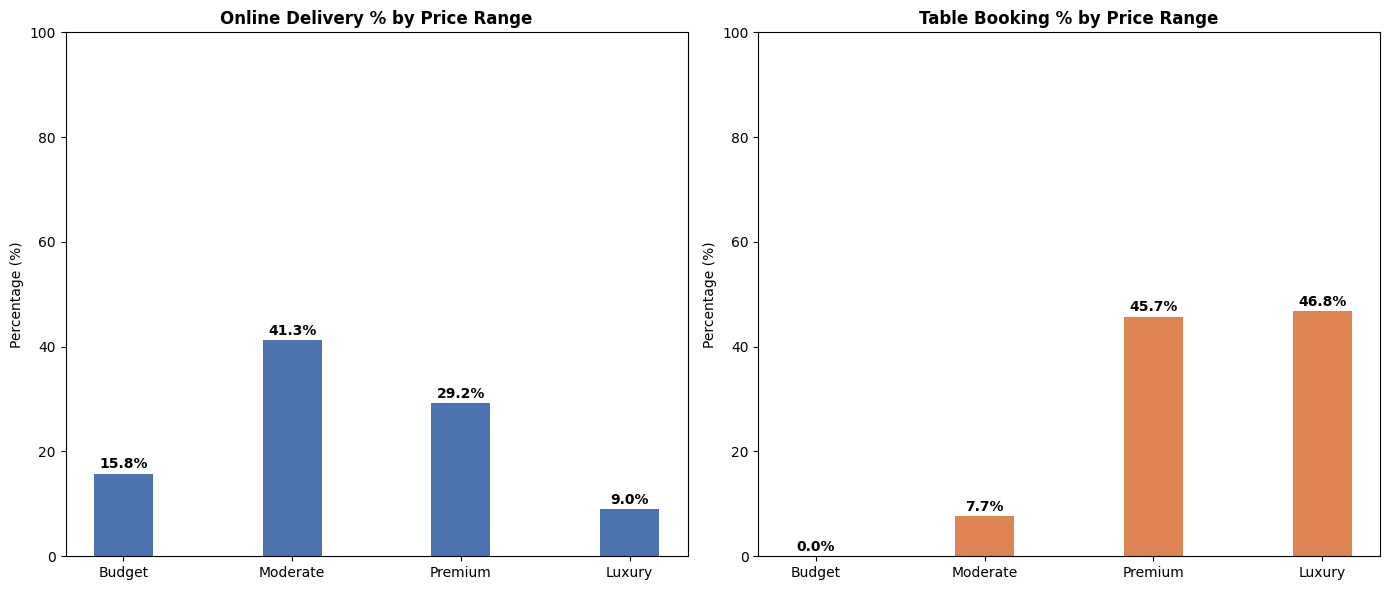

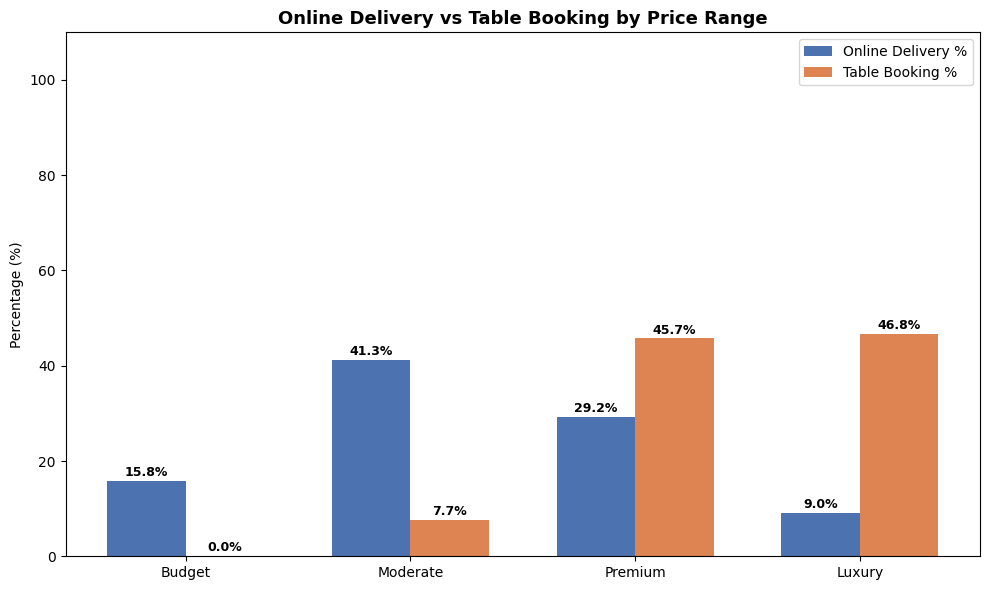

In [ ]:
# Level 3 - Task 3: Price Range vs Online Delivery and Table Booking

price_labels = {1: "Budget", 2: "Moderate", 3: "Premium", 4: "Luxury"}
df["Price Label"] = df["Price range"].map(price_labels)

# Delivery by price range
delivery_by_price = df.groupby("Price range")["Has Online delivery"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(2)

# Table booking by price range
booking_by_price = df.groupby("Price range")["Has Table booking"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(2)

print("Online Delivery % by Price Range")
print("=" * 40)
for pr, pct in delivery_by_price.items():
    print(f"  {price_labels[pr]:<12} : {pct:.2f}%")

print("\nTable Booking % by Price Range")
print("=" * 40)
for pr, pct in booking_by_price.items():
    print(f"  {price_labels[pr]:<12} : {pct:.2f}%")

# Do higher-priced restaurants offer more services?
print("\nConclusion:")
if delivery_by_price.is_monotonic_increasing:
    print("  Higher-priced restaurants offer MORE online delivery.")
else:
    print("  No clear pattern: higher price doesn't always mean more delivery.")

if booking_by_price.is_monotonic_increasing:
    print("  Higher-priced restaurants offer MORE table booking.")
else:
    print("  No clear pattern: higher price doesn't always mean more table booking.")

# Plots
x = np.arange(4)
width = 0.35
labels = [price_labels[i] for i in range(1, 5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grouped bar - delivery
bars1 = axes[0].bar(x, delivery_by_price.values, width,
                    color="#4C72B0", label="Online Delivery %")
axes[0].set_title("Online Delivery % by Price Range", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 100)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{bar.get_height():.1f}%",
                 ha="center", fontweight="bold")

# Grouped bar - table booking
bars2 = axes[1].bar(x, booking_by_price.values, width,
                    color="#DD8452", label="Table Booking %")
axes[1].set_title("Table Booking % by Price Range", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{bar.get_height():.1f}%",
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Combined comparison chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(4)
width = 0.35
bars1 = ax.bar(x - width/2, delivery_by_price.values, width,
               color="#4C72B0", label="Online Delivery %")
bars2 = ax.bar(x + width/2, booking_by_price.values, width,
               color="#DD8452", label="Table Booking %")
ax.set_title("Online Delivery vs Table Booking by Price Range",
             fontweight="bold", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()